In [1]:
# Import the core libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress annoying warnings for a cleaner notebook
import warnings
warnings.filterwarnings('ignore')


In [2]:
# Set the directory path to where the dataset are stored
DATA_DIR = os.path.join('..', 'data', 'raw')

# 1. Load the dataset using pd.read_csv
titanic_df = pd.read_csv(os.path.join(DATA_DIR, 'Titanic-Dataset.csv'))

In [3]:
# View the first 10 rows
print("--- FIRST 10 ROWS ---")
display(titanic_df.head(10))

--- FIRST 10 ROWS ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [4]:
# Examine structure, datatypes, and missing values
print("\n--- DATASET INFO ---")
titanic_df.info()



--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
print("\n--- SUMMARY STATISTICS ---")
display(titanic_df.describe())


--- SUMMARY STATISTICS ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
# Handling Missing Values

# 1. Handle 'Embarked' (Categorical) by filling it with Mode (Most Frequent)
# There are only 2 missing valuespresent in the column so, it's safe to assume they boarded at the most popular port.
mode_embarked = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(mode_embarked)
print(f"Filled missing Embarked with Mode: {mode_embarked}")

# 2. Handle 'Age' (Numerical) by filling it with Median
# I noticed that Age has outliers (max 80). And the Median is most resistant to outliers 
# whereas the Mean would be pulled higher by those older passengers (the outliers).
median_age = titanic_df['Age'].median()
titanic_df['Age'] = titanic_df['Age'].fillna(median_age)
print(f"Filled missing Age with Median: {median_age}")

# 3. Handle 'Cabin' (Excessive Nulls) by dropping the column entirely
# The reason being that 687 out of 891 values are missing (over 77%). Adding this column as a feature would introduce 
# massive bias/noise. The safest decision is to drop it.
titanic_df = titanic_df.drop(columns=['Cabin'])
print("Dropped the 'Cabin' column due to excessive missing data.")

# 4. Check for duplicates in case
duplicates = titanic_df.duplicated().sum() # .duplicated will return a series of True (a duplicate)(= 1) and False (unique)(= 0) in which .sum adds together 
print(f"\nTotal duplicate rows found: {duplicates}")
if duplicates > 0:
    titanic_df = titanic_df.drop_duplicates()
    print("Duplicates removed.")

# Verify the new, clean columns
print("\nNEW MISSING VALUES COUNT")
display(titanic_df.isnull().sum())

Filled missing Embarked with Mode: S
Filled missing Age with Median: 28.0
Dropped the 'Cabin' column due to excessive missing data.

Total duplicate rows found: 0

NEW MISSING VALUES COUNT


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

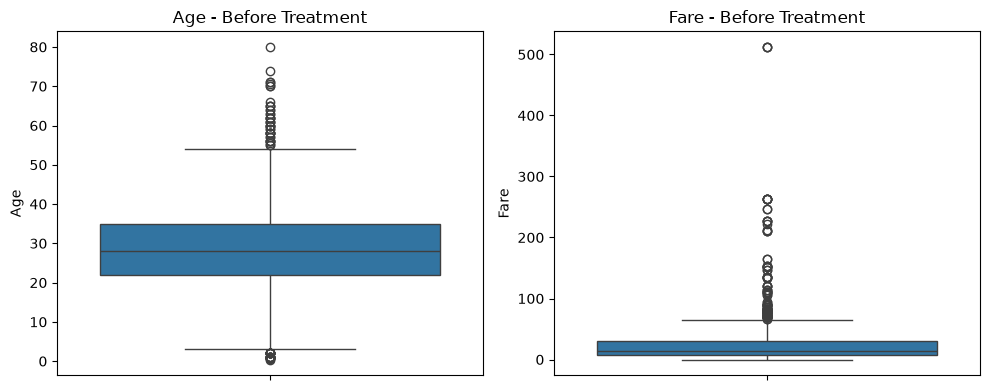

In [7]:
# Plotting initial boxplots to visually detect outliers
plt.figure(figsize=(10, 4)) # 10 inches on the X axis and 4 inches on the Y axis

plt.subplot(1, 2, 1) # Meaning a sub plot with 1 row, 2 column and this is the 1st plot
sns.boxplot(y=titanic_df['Age'])
plt.title('Age - Before Treatment')

plt.subplot(1, 2, 2) # Meaning a sub plot with 1 row, 2 column and this is the 2nd plot
sns.boxplot(y=titanic_df['Fare'])
plt.title('Fare - Before Treatment')

plt.tight_layout()
plt.show()


In [8]:
# Based on the Box plot we can see that both the Age and Fare columns contains outliers
# Outliers confuse ML alogoithms so it is required that they are caped when needed
# I decided to retain the age outliers are they are real ages which will not really affect the dataset
# I decided to cap the Fare column as the box plot indicated that those above 100 are outliers, 
# i.e VIPs who paid a whole lot more than average people. This outliers will definitely confuse a ML algorithm
# We are going with the interquatile range method of capping outliers, the formula is the same formula use in the box plot graph

# Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = titanic_df['Fare'].quantile(0.25)
Q3 = titanic_df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Define the absolute maximum limit (1.5 times the IQR above Q3) (same formula used for the blue box (1st and 3rd quantile) and whiskers of the box plot)
upper_boundary = Q3 + 1.5 * IQR

# Use numpy's 'where' function to cap values exceeding the boundary
titanic_df['Fare'] = np.where(titanic_df['Fare'] > upper_boundary, upper_boundary, titanic_df['Fare'])

print(f"Reasoning: Age outliers retained (valid demographic data).")
print(f"Reasoning: Fare outliers capped at {upper_boundary:.2f} using IQR method to prevent model skewness.")

print("\n--- SUMMARY AFTER OUTLIER TREATMENT ---")
display(titanic_df[['Age', 'Fare']].describe())

Reasoning: Age outliers retained (valid demographic data).
Reasoning: Fare outliers capped at 65.63 using IQR method to prevent model skewness.

--- SUMMARY AFTER OUTLIER TREATMENT ---


,Age,Fare
count,891.000000,891.000000
mean,29.361582,24.046813
std,13.019697,20.481625
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,65.634400


Text(0.5, 1.0, 'Fare - After Treatment')

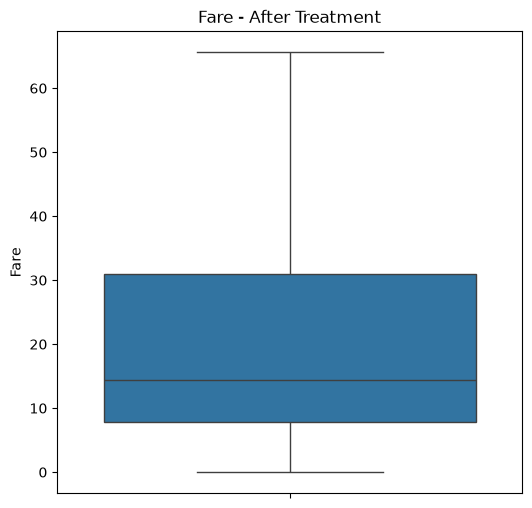

In [9]:
plt.figure(figsize=(6,6))
sns.boxplot(y=titanic_df['Fare'])
plt.title('Fare - After Treatment')

In [10]:
# Categorical Variable Encoding

# 1. Drop columns that offer no predictive value for ML
# PassengerId is just an index, Name and Ticket are random text that will not help in the model prediction
titanic_df = titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
print("Dropped non-predictive columns: PassengerId, Name, Ticket")

# 2. Label Encoding for 'Sex' (Binary: 0 or 1)
# Label encoding is useful here with no side effect (the model thinking 2 is grester than 1) because it is binary
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})
print("Encoded 'Sex': Male -> 0, Female -> 1")

# 3. One-Hot Encoding for 'Embarked' (>2 categories)
# drop_first=True prevents the "dummy variable trap" (perfect multicollinearity)
# This is a feature unique to Linear Models (Linear Regression, Logistic Regression) 
# and distance-based models like Neural Networks or SVMs
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], drop_first=True, dtype=int)
print("One-Hot Encoded 'Embarked' into dummy columns.")



Dropped non-predictive columns: PassengerId, Name, Ticket
Encoded 'Sex': Male -> 0, Female -> 1
One-Hot Encoded 'Embarked' into dummy columns.


In [11]:
titanic_df.head(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,1
1,1,1,1,38.0,1,0,65.6344,0,0
2,1,3,1,26.0,0,0,7.9250,0,1
3,1,1,1,35.0,1,0,53.1000,0,1
4,0,3,0,35.0,0,0,8.0500,0,1
5,0,3,0,28.0,0,0,8.4583,1,0
6,0,1,0,54.0,0,0,51.8625,0,1
7,0,3,0,2.0,3,1,21.0750,0,1
8,1,3,1,27.0,0,2,11.1333,0,1
9,1,2,1,14.0,1,0,30.0708,0,0


In [26]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Initialize the scaler
scaler = StandardScaler() # Scaling using Z score

# Apply scaler to our continuous numerical features (mean of 0 and Standard Deviation of 1)
titanic_df[['Age', 'Fare']] = scaler.fit_transform(titanic_df[['Age', 'Fare']])
print("Applied StandardScaler to 'Age' and 'Fare'.")

# View the machine-learning-ready data!
print("\nFINAL PREPROCESSED DATASET")
display(titanic_df.head())

KeyError: "['Fare'] not in index"

(array([549.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 342.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

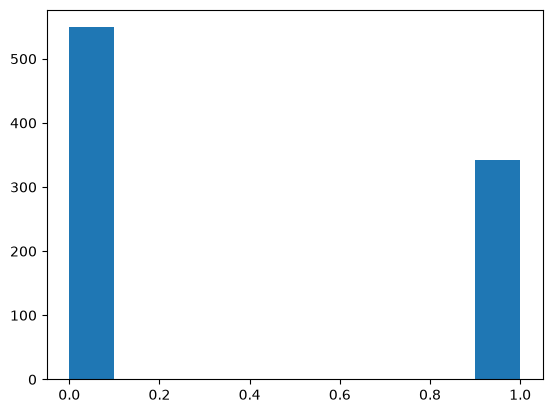

In [13]:
plt.hist(titanic_df['Survived'])

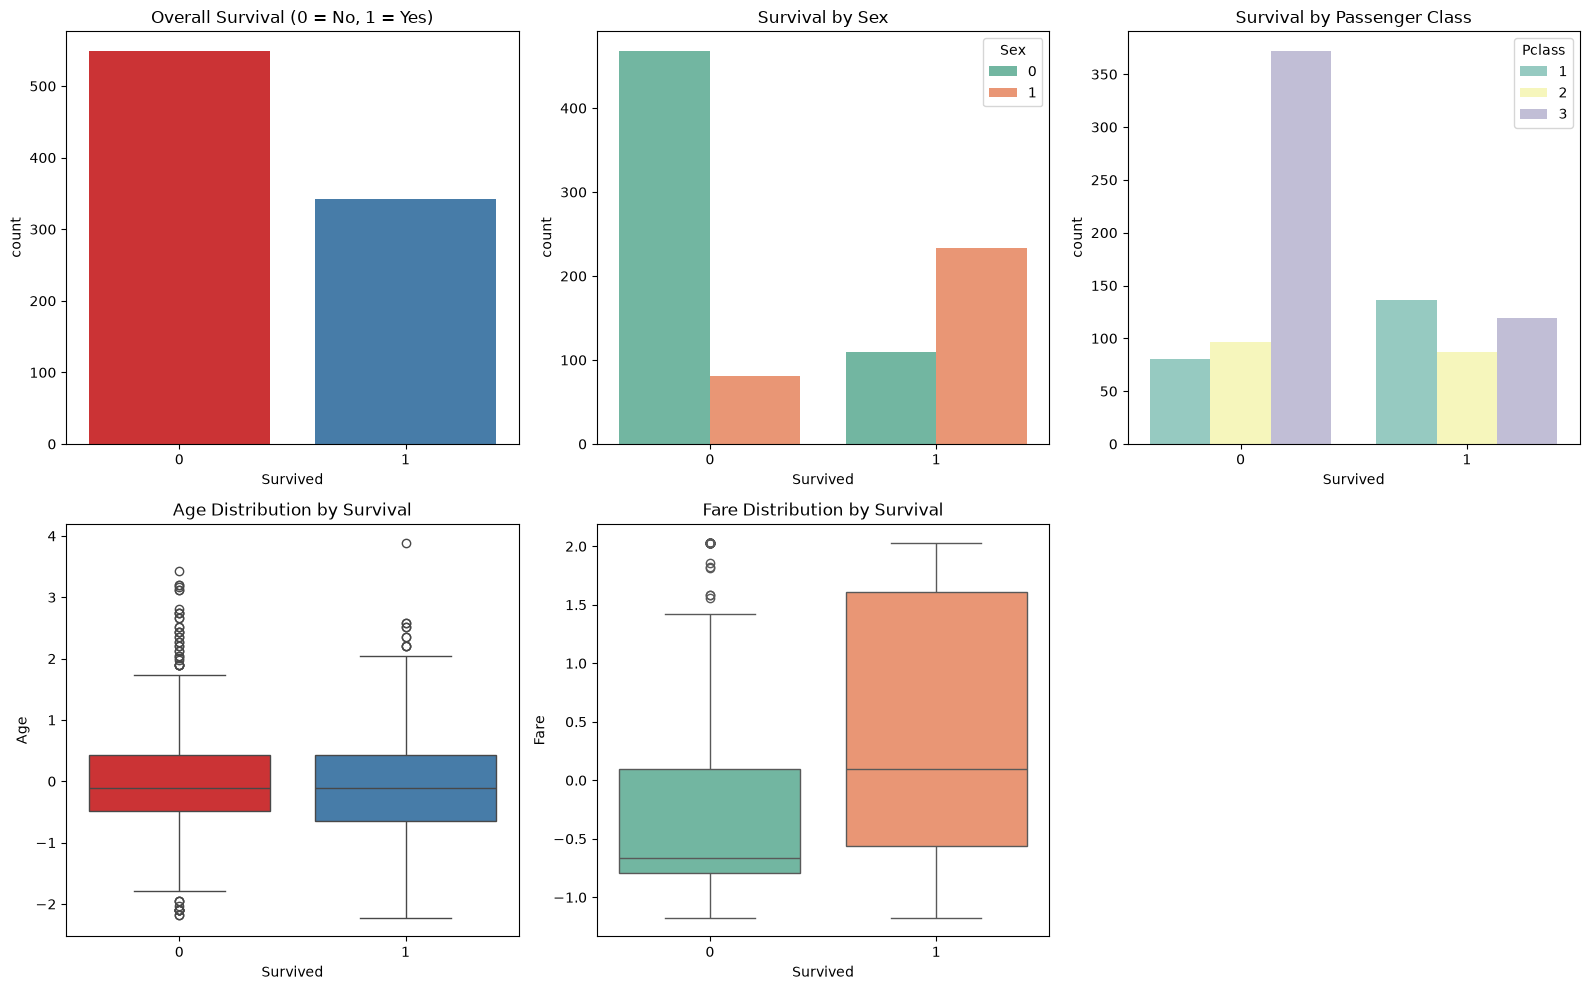

In [14]:
# Part 3: Exploratory Data Analysis (EDA)

# Set up the visualization grid
plt.figure(figsize=(16, 10))

# --- 3A: Univariate Analysis ---
# 1. Target Variable Distribution (Survived)
plt.subplot(2, 3, 1)
sns.countplot(x='Survived', data=titanic_df, palette='Set1')
plt.title('Overall Survival (0 = No, 1 = Yes)')

# --- 3B: Bivariate Analysis ---
# 2. Survival vs. Sex (0 = Male, 1 = Female)
plt.subplot(2, 3, 2)
sns.countplot(x='Survived', hue='Sex', data=titanic_df, palette='Set2')
plt.title('Survival by Sex')

# 3. Survival vs. Passenger Class
plt.subplot(2, 3, 3)
sns.countplot(x='Survived', hue='Pclass', data=titanic_df, palette='Set3')
plt.title('Survival by Passenger Class')

# 4. Age vs. Survival
plt.subplot(2, 3, 4)
sns.boxplot(x='Survived', y='Age', data=titanic_df, palette='Set1')
plt.title('Age Distribution by Survival')

# 5. Fare vs. Survival
plt.subplot(2, 3, 5)
sns.boxplot(x='Survived', y='Fare', data=titanic_df, palette='Set2')
plt.title('Fare Distribution by Survival')

plt.tight_layout()
plt.show()

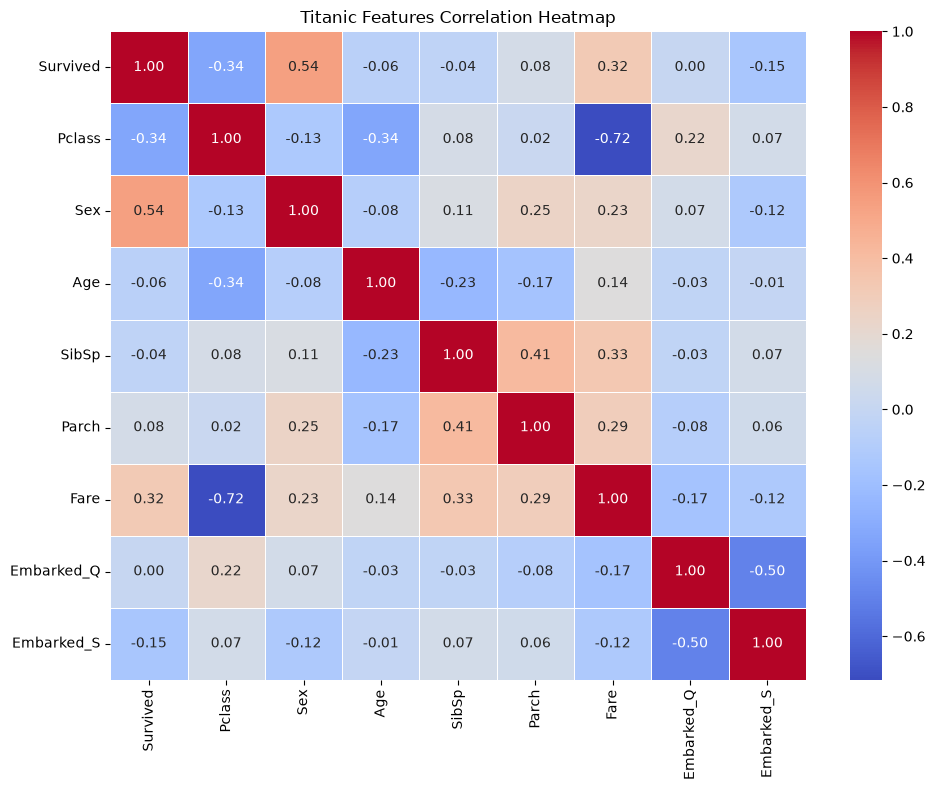


--- CORRELATION WITH TARGET VARIABLE (SURVIVED) ---
Survived      1.000000
Sex           0.543351
Fare          0.317430
Parch         0.081629
Embarked_Q    0.003650
SibSp        -0.035322
Age          -0.064910
Embarked_S   -0.149683
Pclass       -0.338481
Name: Survived, dtype: float64


In [15]:
# Part 4: Correlation Analysis & Feature Understanding

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

# Calculate the Pearson correlation matrix for all columns
correlation_matrix = titanic_df.corr()

# annot=True shows the exact Pearson numbers inside the boxes
# cmap='coolwarm' makes negative correlations blue and positive correlations red
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Titanic Features Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print out the correlations specifically with our Target ('Survived')
print("\n--- CORRELATION WITH TARGET VARIABLE (SURVIVED) ---")
print(correlation_matrix['Survived'].sort_values(ascending=False))

In [16]:
import sys

# Dropping 'Fare' due to multicollinearity with 'Pclass' (-0.72)
titanic_df = titanic_df.drop(columns=['Fare'])
print("Dropped 'Fare' column to resolve multicollinearity with 'Pclass'.")

# View the final resulting dataframe
print("\n--- FINAL TITANIC FEATURES ---")
print(titanic_df.columns.tolist())



Dropped 'Fare' column to resolve multicollinearity with 'Pclass'.

--- FINAL TITANIC FEATURES ---
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Embarked_Q', 'Embarked_S']


In [47]:
# Export the cleaned dataset
DATA_PROCESSED = os.path.join('..', 'data', 'processed')
os.makedirs(DATA_PROCESSED, exist_ok=True)

titanic_df.to_csv(os.path.join(DATA_PROCESSED, 'titanic_cleaned.csv' ), index=False)
print("\nSuccess: Dataset exported as 'titanic_cleaned.csv'")


Success: Dataset exported as 'titanic_cleaned.csv'


In [34]:
# Iris Dataset 


# Load dataset using pd.read_csv
iris_df = pd.read_csv(os.path.join(DATA_DIR, 'Iris.csv'))

print("--- IRIS DATASET: FIRST 5 ROWS ---")
display(iris_df.head(10))


--- IRIS DATASET: FIRST 5 ROWS ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [35]:
print("--- DATASET INFO ---")
iris_df.info()

--- DATASET INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [36]:
print("\n--- SUMMARY STATISTICS ---")
display(iris_df.describe())



--- SUMMARY STATISTICS ---


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [37]:
print("\n--- TARGET CLASS DISTRIBUTION ---")
print(iris_df['Species'].value_counts())


--- TARGET CLASS DISTRIBUTION ---
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


In [38]:
# Preprocessing, Outlier Detection, & Scaling

# Drop the 'Id' column if it exists (it's just a row number, no predictive value)
if 'Id' in iris_df.columns:
    iris_df = iris_df.drop(columns=['Id'])
    print("Dropped non-predictive 'Id' column.")

# Check for and drop exact duplicate rows
duplicates = iris_df.duplicated().sum()
print(f"Total duplicate rows found: {duplicates}")
if duplicates > 0:
    iris_df = iris_df.drop_duplicates()
    print("Duplicates removed.")



Dropped non-predictive 'Id' column.
Total duplicate rows found: 3
Duplicates removed.


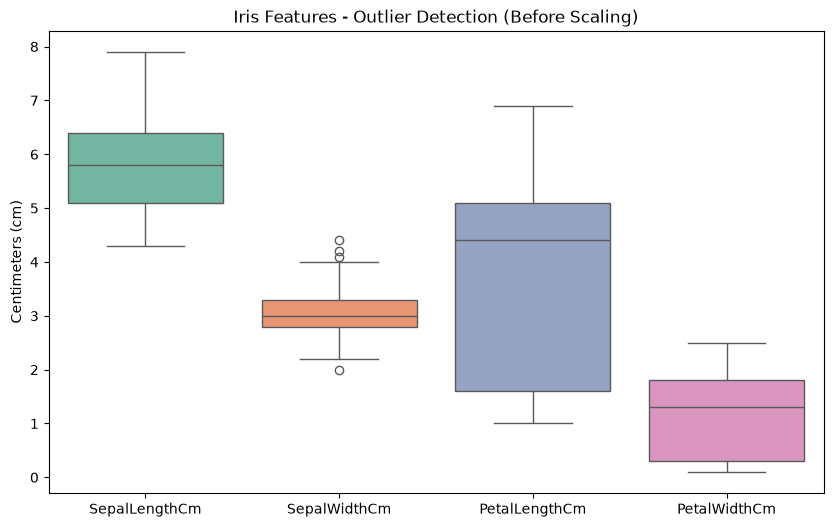

In [ ]:
# Isolate numeric columns for outlier detection (ignoring our target column)
# The select_dtypes is used as you can indicate the partcular datatype you want your columns to have
numeric_cols = iris_df.select_dtypes(include=['float64', 'int64']).columns

# Visualizing Outliers across all 4 features
# X is automatically set as the columns in the dataframe 
plt.figure(figsize=(10, 6))
sns.boxplot(data=iris_df[numeric_cols], palette="Set2")
plt.title('Iris Features - Outlier Detection (Before Scaling)')
plt.ylabel('Centimeters (cm)')
plt.show()



In [ ]:
# Encode the Target Variable (Species -> 0, 1, 2)
le = LabelEncoder()
# We dynamically use your target_col variable from Phase 1
iris_df['Species']= le.fit_transform(iris_df['Species'])
print(f"\nEncoded Species Mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")




Encoded Species Mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [ ]:
# Apply Feature Scaling to numerical columns
# Scaling is done as a result of the fact that ML algorithms are mathematical models 
# They are easily affected by having a single feature having a very large value compared to other feature. 
# They mess up the weights for the models
# Standard Scaler makes use of the Z-score method where the mean is 0 and the standard deviation is 1
scaler = StandardScaler()
iris_df[numeric_cols] = scaler.fit_transform(iris_df[numeric_cols])
print("\nApplied StandardScaler to all continuous features.")

# View the preprocessed matrix
print("\n--- PREPROCESSED IRIS DATA (First 5 Rows) ---")
display(iris_df.head())


Applied StandardScaler to all continuous features.

--- PREPROCESSED IRIS DATA (First 5 Rows) ---


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,-0.915509,1.019971,-1.357737,-1.3357,0
1,-1.157560,-0.128082,-1.357737,-1.3357,0
2,-1.399610,0.331139,-1.414778,-1.3357,0
3,-1.520635,0.101529,-1.300696,-1.3357,0
4,-1.036535,1.249582,-1.357737,-1.3357,0


Generating Pairplot to visualize multi-class decision boundaries...


<Figure size 1200x800 with 0 Axes>

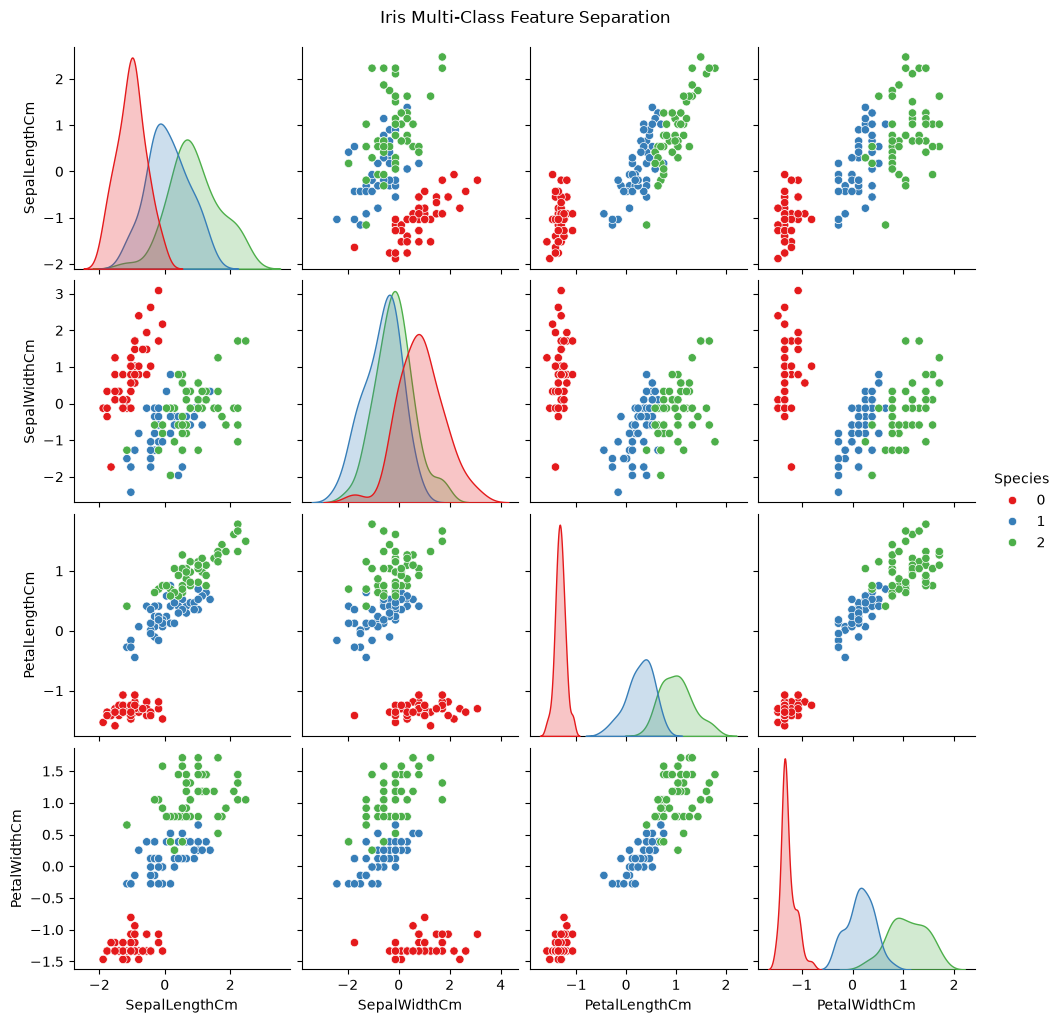

In [ ]:
# Exploratory Data Analysis (EDA)

print("Generating Pairplot to visualize multi-class decision boundaries...")

# We use sns.pairplot to plot every feature against every other feature.
# hue='Species' colors the data points based on their target class (0, 1, 2)
# diag_kind='kde' creates smooth distribution curves down the middle diagonal
# this ensures that we can quickly make infrence on features that are useful,
# an overlap in the KDE is a bad feature while no overlap indicates a good feature.
plt.figure(figsize=(12, 8))
sns.pairplot(iris_df, hue='Species', palette='Set1', diag_kind='kde')
plt.suptitle('Iris Multi-Class Feature Separation', y=1.02)
plt.tight_layout
plt.show()

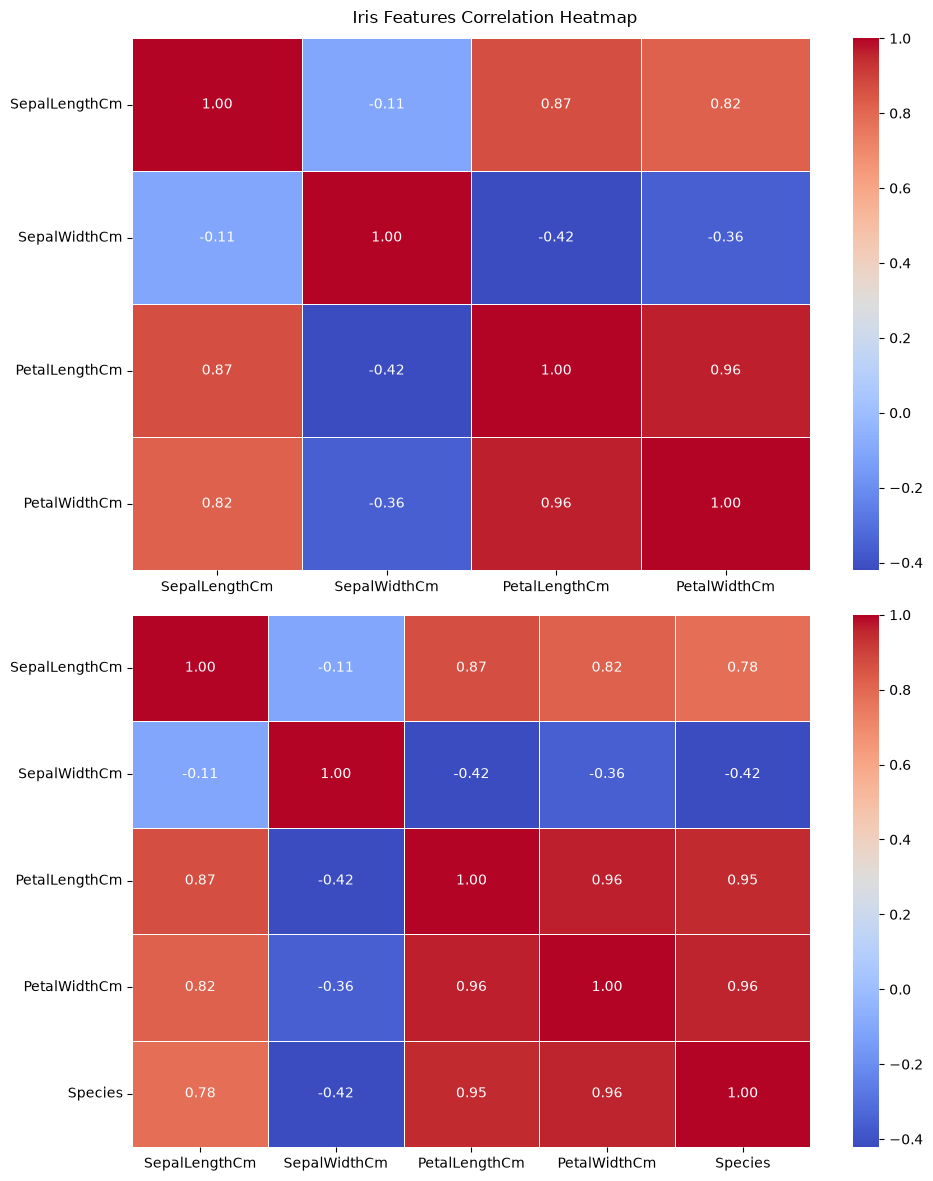

In [ ]:
plt.figure(figsize=(10, 12))

# We see how the 4 physical features interact with each other and with the Target 'Species'.
corr_matrix = iris_df.drop(columns=['Species']).corr()
corr_matrix_all = iris_df.corr()

plt.subplot(2,1,1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.subplot(2,1,2)
sns.heatmap(corr_matrix_all, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.suptitle('Iris Features Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
# Exporting the ML-Ready Iris Dataset

# Optional TinyML Memory Optimization: 
# iris_df = iris_df.drop(columns=['PetalWidthCm']) 
# print("Dropped PetalWidthCm due to high correlation (0.96) with PetalLengthCm.")

iris_df.to_csv(os.path.join(DATA_PROCESSED, 'iris_cleaned.csv'), index=False)
print("Success: Cleaned multi-class dataset exported as 'iris_cleaned.csv'")

Success: Cleaned multi-class dataset exported as 'iris_cleaned.csv'
